keeping the second conv block's stride as (1,1) instead of (2,1) that changes the output from the ATN module  from (B,2,32,2) to (B,4,32,2), hence allowing a bigger matrix to be sent for compression preserving more information according to me :)

reducing number of epochs and paitence of the lr scheduler 

increasing the CR from 8 to 16 reducing the size of vector from 32 to 16

# dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = np.load("../MIXEDR4_114dsei00/MIXEDR4_114dsei00.npy")
real = data[:, 0, :, :]
imag = data[:, 1, :, :]

df = pd.DataFrame({
    "real": list(real),   # each element is a (13,32) ndarray
    "imag": list(imag)
})


In [3]:
df.head()

,real,imag
0,"[[0.21466087, -0.17984532, 0.015546491, -0.122...","[[0.0, 0.12983207, 0.17724419, -0.1369922, 0.0..."
1,"[[0.15750813, -0.030407492, 0.17322381, 0.0119...","[[0.0, -0.18515831, 0.040723186, -0.19621779, ..."
2,"[[0.21564163, -0.053608317, 0.15069366, 0.1825...","[[0.0, -0.17658131, 0.22834276, -0.18058468, 0..."
3,"[[0.085004166, -0.017324746, 0.042449176, -0.0...","[[0.0, 0.04596916, -0.007453814, 0.0012580045,..."
4,"[[0.24709222, -0.23738584, 0.13368812, -0.1340...","[[0.0, -0.0048156795, -0.19413038, 0.19853236,..."


In [4]:
data.shape

(500000, 2, 13, 32)

In [5]:
import numpy as np
import torch

class CSIDataCollater:
    def __init__(self, batch_size=200, snr_low=-10.0, snr_high=10.0):
        self.batch_size = batch_size
        self.snr_low = snr_low
        self.snr_high = snr_high
        
        # Define indices based on the provided image distribution
        self.indices_map = {
            "train": list(range(0, 400000)),
            "val": list(range(400000, 450000)),
            "test": list(range(450000, 500000))
        }

    def __call__(self, data_array, mode="train"):
        """
        data_array: numpy array of shape (500000, 2, 13, 32)
        mode: "train", "val", or "test"
        """
        # 1. Get the relevant range of indices for the current mode
        possible_indices = self.indices_map[mode]
        
        # 2. Randomly sample indices for the batch
        selected_indices = np.random.choice(possible_indices, self.batch_size, replace=False)
        batch_csi = data_array[selected_indices]  # Shape: (B, 2, 13, 32)
        
        # 3. Permute to (B, 13, 32, 2)
        batch_csi = np.transpose(batch_csi, (0, 2, 3, 1))
        
        # 4. Sample SNR from uniform distribution [-10, 10] dB [cite: 445]
        batch_snr = np.random.uniform(self.snr_low, self.snr_high, (self.batch_size, 1))
        
        return torch.from_numpy(batch_csi).float(), torch.from_numpy(batch_snr).float()

In [6]:

# Usage
collater = CSIDataCollater()
csi_batch, snr_batch = collater(data)

In [7]:
csi_batch.shape, snr_batch.shape

(torch.Size([200, 13, 32, 2]), torch.Size([200, 1]))

## AF module

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AFModule(nn.Module):
    def __init__(self, channels, reduction_ratio=2):
        """
        AF Module (Attention Feature Module)
        Args:
            channels: Number of input feature channels (C).
            reduction_ratio: Ratio for the hidden layer size in the MLP. 
                             Since channels are small (16), we can use a small ratio or no reduction.
        """
        super(AFModule, self).__init__()
        
        # 1. Context Extraction is handled in forward (Global Avg Pooling + Concat)
        
        # 2. Factor Prediction (MLP)
        # Input size = Channels (from Global Avg Pool) + 1 (from SNR mu)
        input_dim = channels + 1 
        hidden_dim = max(channels // reduction_ratio, 1) # Ensure hidden dim is at least 1
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, snr):
        """
        Args:
            x: Feature map tensor of shape (Batch, Channels, Height, Width)
            snr: Signal-to-Noise Ratio tensor of shape (Batch, 1)
        """
        batch, channels, height, width = x.size()

        # --- 1. Context Extraction ---
        # Global Average Pooling: Average over H and W dimensions -> (Batch, Channels)
        global_feat = F.avg_pool2d(x, (height, width)).view(batch, channels)
        
        # Concatenation: Combine global features with SNR
        # global_feat: (B, C), snr: (B, 1) -> context: (B, C+1)
        context = torch.cat([global_feat, snr], dim=1)

        # --- 2. Factor Prediction ---
        # Pass through MLP to get scale factors
        out = self.fc1(context)
        out = self.relu(out)
        out = self.fc2(out)
        scale_factors = self.sigmoid(out) # Shape: (Batch, Channels)

        # --- 3. Feature Recalibration ---
        # Reshape scale factors to (Batch, Channels, 1, 1) for broadcasting
        scale_factors = scale_factors.view(batch, channels, 1, 1)
        
        # Element-wise multiplication
        out = x * scale_factors
        
        return out



## ATN module

In [9]:
import torch
import torch.nn as nn

class ATN(nn.Module):
    def __init__(self):
        super(ATN, self).__init__()
        
        # --- Block 1 ---
        # H: 13 -> 7 (Stride 2: floor((13 + 2*1 - 3)/2 + 1) = 7)
        self.conv1 = nn.Conv2d(in_channels=2, out_channels=16, 
                               kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
        self.bn1 = nn.BatchNorm2d(16)
        self.prelu1 = nn.PReLU()
        self.af1 = AFModule(channels=16)

        # --- Block 2 ---
        # MODIFIED: Stride changed from (2, 1) to (1, 1)
        # H: 7 -> 7 (Stride 1 preserves size with padding 1 and kernel 3)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, 
                               kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        self.bn2 = nn.BatchNorm2d(16)
        self.prelu2 = nn.PReLU()
        self.af2 = AFModule(channels=16)

        # --- Block 3 ---
        # H: 7 -> 4 (Stride 2: floor((7 + 2*1 - 3)/2 + 1) = 4)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=2, 
                               kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
        self.bn3 = nn.BatchNorm2d(2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, snr):
        """
        Input x: (B, 13, 32, 2)
        Output x: (B, 4, 32, 2)
        """
        x = x.permute(0, 3, 1, 2) # (B, 2, 13, 32)
        
        # Block 1
        x = self.conv1(x)       # (B, 16, 7, 32)
        x = self.bn1(x)
        x = self.prelu1(x)
        x = self.af1(x, snr)

        # Block 2
        x = self.conv2(x)       # (B, 16, 7, 32) <- Height preserved here
        x = self.bn2(x)
        x = self.prelu2(x)
        x = self.af2(x, snr)

        # Block 3
        x = self.conv3(x)       # (B, 2, 4, 32) <- Final downsampling to 4
        x = self.bn3(x)
        x = self.sigmoid(x)

        x = x.permute(0, 2, 3, 1) # (B, 4, 32, 2)
        return x

In [10]:

if __name__ == "__main__":
    # 1. Setup Input with Batch Size = 200
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Input format: (Batch, Height, Width, Channels) -> (200, 13, 32, 2)
    input_tensor = csi_batch.to(device)
    
    # 2. Setup SNR (mu)
    # One SNR value per image in the batch -> (200, 1)
    snr_tensor = snr_batch.to(device)

    # 3. Initialize Model
    model = ATN().to(device)

    # 4. Forward Pass
    output_tensor = model(input_tensor, snr_tensor)

    # 5. Print Dimensions
    print("--- Dimension Check ---")
    print(f"Input Shape:  {input_tensor.shape}")  # Expected: (200, 13, 32, 2)
    print(f"Output Shape: {output_tensor.shape}") # Expected: (200, 4, 32, 2)


--- Dimension Check ---
Input Shape:  torch.Size([200, 13, 32, 2])
Output Shape: torch.Size([200, 4, 32, 2])


## encoder

In [11]:
import torch
import torch.nn as nn

class CsiNetPlusEncoderWithAF(nn.Module):
    def __init__(self, compression_ratio=16):
        """
        ADJSCC-CSI Encoder modified for Input shape: [B, 4, 32, 2]
        """
        super(CsiNetPlusEncoderWithAF, self).__init__()
        
        # --- Constants Updated ---
        self.input_channels = 4  # Updated from 2 to 4
        self.height = 32
        self.width = 2
        # Total elements now: 4 * 32 * 2 = 256
        self.total_elements = self.input_channels * self.height * self.width 
        self.M = int(self.total_elements / compression_ratio)
        
        # --- 1. First Convolutional Block ---
        self.conv1 = nn.Conv2d(in_channels=self.input_channels, # Accepts 4 channels
                               out_channels=4, 
                               kernel_size=7, 
                               stride=1, 
                               padding=3)
        self.bn1 = nn.BatchNorm2d(num_features=4)
        self.act1 = nn.LeakyReLU(negative_slope=0.3, inplace=True)

        self.af1 = AFModule(channels=4)

        # --- 2. Second Convolutional Block ---
        # Stays 4 -> 4 as it processes the features from the first block
        self.conv2 = nn.Conv2d(in_channels=4, 
                               out_channels=4, 
                               kernel_size=7, 
                               stride=1, 
                               padding=3)
        self.bn2 = nn.BatchNorm2d(num_features=4)
        self.act2 = nn.LeakyReLU(negative_slope=0.3, inplace=True)
        
        self.af2 = AFModule(channels=4)
        
        # --- 3. Fully Connected Layer ---
        # 'in_features' is now 256 (if total_elements is calculated correctly above)
        self.fc = nn.Linear(in_features=self.total_elements, out_features=self.M)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, snr):
        """
        Args:
            x: Input tensor [B, 4, 32, 2]
            snr: SNR value tensor [B, 1]
        """
        # Step 1: First Conv Block + AF (Reduces channels from 4 to 2)
        out = self.conv1(x)
        out = self.bn1(out) 
        out = self.act1(out)
        out = self.af1(out, snr) 
        
        # Step 2: Second Conv Block + AF
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.act2(out)
        out = self.af2(out, snr)
        
        # Step 3: Flatten (B, 2, 32, 2) -> (B, 128)
        # Note: Even though input started at 256 elements, 
        # the conv layers reduced depth to 2, so we end with 128 features here.
        out = out.view(out.size(0), -1)
        
        # Step 4: FC Layer
        # If in_features was 256, but out.view results in 128, 
        # we need to adjust the FC layer or keep out_channels at 4.
        # FIX: See note below.
        out = self.fc(out) 
        out = self.sigmoid(out)
        
        return out

In [12]:
# --- Verification Example ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    B = 200
    
    # Instantiate Modified Encoder
    model = CsiNetPlusEncoderWithAF(compression_ratio=16).to(device)
    
    # Dummy Input [B, 2, 32, 2]
    dummy_input = output_tensor.to(device)

    dummy_snr = snr_batch.to(device)
    
    # Forward Pass with SNR
    output = model(dummy_input, dummy_snr)
    
    print(f"Input Shape: {dummy_input.shape}")
    print(f"SNR Shape: {dummy_snr.shape}")
    print(f"Output Shape: {output.shape}")
    print(f"AF Modules Successfully Integrated.")

Input Shape: torch.Size([200, 4, 32, 2])
SNR Shape: torch.Size([200, 1])
Output Shape: torch.Size([200, 16])
AF Modules Successfully Integrated.


In [13]:
output[0]

tensor([0.5015, 0.4741, 0.5909, 0.6353, 0.5723, 0.5491, 0.5555, 0.4214, 0.5562,
        0.5100, 0.4414, 0.4851, 0.4862, 0.4232, 0.3888, 0.5188],
       device='cuda:0', grad_fn=<SelectBackward0>)

## real to complex symbols and power normalization

In [14]:
import torch

def enc_to_complex_and_normalize(encoder_output):
    """
    Converts real-valued encoder output to complex representation and 
    applies power normalization.

    Args:
        encoder_output (torch.Tensor): Output from encoder with shape [B, 2k] 
                                       (e.g., [B, 16]).
    
    Returns:
        torch.Tensor: Normalized complex symbols with shape [B, k] (e.g., [B, 8]).
    """
    
    # --- Step 1: Real-to-Complex Conversion [cite: 146, 324] ---
    # The paper mentions combining real values to form complex values.
    # As discussed, we split the [B, 16] vector into two [B, 8] vectors.
    
    # Calculate k (half the dimension of the real vector)
    k = encoder_output.shape[1] // 2 
    
    # Slicing: First k elements = Real (I), Remaining k elements = Imaginary (Q)
    real_part = encoder_output[:, :k]
    imag_part = encoder_output[:, k:]
    
    # Create the complex tensor s
    s = torch.complex(real_part, imag_part)
    
    # --- Step 2: Power Normalization  ---
    # Constraint: (1/k) * E(s * s*) = 1
    # We normalize by the square root of the average power over the batch 
    # to satisfy the expectation E[...] = 1.
    
    # Calculate the average power of the current batch
    # |s|^2 = real^2 + imag^2
    batch_avg_power = torch.mean(s.abs().square())
    
    # Normalize the complex vector s
    # We divide by sqrt(P_avg) so that the new P_avg becomes 1
    s_normalized = s / torch.sqrt(batch_avg_power)
    
    return s_normalized



In [15]:

encoder_output = output

# Apply conversion and normalization
complex_symbols = enc_to_complex_and_normalize(encoder_output)

print("Input Shape:      ", encoder_output.shape)  # Should be [4, 16]
print("Output Shape:     ", complex_symbols.shape) # Should be [4, 8]
print("Output Data Type: ", complex_symbols.dtype) # Should be complex64

# --- Verification of Power Constraint ---
# The mean power of the output should be approximately 1.0
actual_power = torch.mean(complex_symbols.abs().square())
print(f"Average Power:     {actual_power.item():.4f}")

Input Shape:       torch.Size([200, 16])
Output Shape:      torch.Size([200, 8])
Output Data Type:  torch.complex64
Average Power:     1.0000


In [16]:
complex_symbols[0]

tensor([0.7004+0.7767j, 0.6621+0.7123j, 0.8252+0.6165j, 0.8873+0.6775j,
        0.7993+0.6791j, 0.7668+0.5910j, 0.7758+0.5430j, 0.5885+0.7245j],
       device='cuda:0', grad_fn=<SelectBackward0>)

## modeling channel

In [17]:
import torch
import torch.nn as nn

class WirelessChannelSimulator(nn.Module):
    def __init__(self, num_bs_antennas=32):
        """
        Simulates the wireless channel for CSI feedback as described in the paper.
        
        Args:
            num_bs_antennas (int): Nt, number of antennas at the BS. 
                                   Paper uses Nt=32 in experiments[cite: 406].
        """
        super().__init__()
        self.Nt = num_bs_antennas

    def forward(self, s, snr_db):
        """
        Args:
            s (torch.Tensor): Complex symbols of shape [B, K]. 
                              Represents the encoded vector 's' mapped to subcarriers.
                              **Assumes Power Normalization is already applied.**
            snr_db (torch.Tensor): Signal-to-Noise Ratio in dB for each example.
                                   Shape: [B, 1].

        Returns:
            torch.Tensor: Recovered symbols s_hat of shape [B, K] after MRC.
        """
        batch_size, k = s.shape
        device = s.device

        # 1. Generate Uplink Channel Coefficients (h_u)
        # Using Rayleigh Fading h_u ~ CN(0, I) as a proxy for the paper's channel.
        # Shape: [B, K, Nt]
        h_u_real = torch.randn(batch_size, k, self.Nt, device=device)
        h_u_imag = torch.randn(batch_size, k, self.Nt, device=device)
        # Normalize so variance is 1 (standard complex normal)
        h_u = torch.complex(h_u_real, h_u_imag) * (1/torch.sqrt(torch.tensor(2.0)))

        # 2. Generate AWGN Noise (z)
        # y_i = h_u^i * s_i + z_i (Eq. 2)
        # Calculate noise deviation per batch item based on its specific SNR
        # P_signal = 1 (assumed normalized)
        # P_noise = 1 / 10^(SNR/10)
        snr_linear = 10 ** (snr_db / 10.0) # Shape: [B, 1]
        noise_power = 1.0 / snr_linear
        noise_std = torch.sqrt(noise_power / 2.0) # /2 for splitting into real/imag

        # Reshape noise_std for broadcasting: [B, 1] -> [B, 1, 1]
        # This allows multiplication with noise tensor of shape [B, K, Nt]
        noise_std = noise_std.unsqueeze(-1)

        # Generate standard noise and scale by calculated std
        z_real = torch.randn(batch_size, k, self.Nt, device=device) * noise_std
        z_imag = torch.randn(batch_size, k, self.Nt, device=device) * noise_std
        z = torch.complex(z_real, z_imag) # Shape: [B, K, Nt]

        # 3. Transmission (Eq. 2)
        # Expand s to broadcast: [B, K] -> [B, K, 1] for multiplication with [B, K, Nt] channel
        s_expanded = s.unsqueeze(-1) 
        
        # Received signal y at BS antennas
        y = h_u * s_expanded + z  # Shape: [B, K, Nt]

        # 4. Maximum Ratio Combining (MRC) at BS (Eq. 3) [cite: 196-199]
        # The combining vector w_i = h_u^i / ||h_u^i||_2
        # Norm over antenna dimension (Nt)
        h_norm = torch.norm(h_u, dim=2, keepdim=True) # Shape: [B, K, 1]
        
        # Avoid division by zero
        h_norm = torch.clamp(h_norm, min=1e-8)
        
        w = h_u / h_norm # Shape: [B, K, Nt]

        # s_hat_i = w_i^H * y_i
        # Sum over antennas (dim=2)
        s_hat = torch.sum(torch.conj(w) * y, dim=2) # Shape: [B, K]

        return s_hat



In [18]:
# --- Usage Example ---
if __name__ == "__main__":

    Nt = 32 
    
    input_symbols = complex_symbols

    snr_db = snr_batch

    # Initialize Simulator
    channel_sim = WirelessChannelSimulator(num_bs_antennas=Nt).to(device)

    # Simulate Transmission
    received_symbols = channel_sim(input_symbols.to(device), snr_db.to(device))

    print(f"Input Symbols Shape: {input_symbols.shape}") # [B, K]
    print(f"SNR Shape: {snr_db.shape}")                 # [B, 1]
    print(f"Output Symbols Shape: {received_symbols.shape}") # [B, K]
    
    

Input Symbols Shape: torch.Size([200, 8])
SNR Shape: torch.Size([200, 1])
Output Symbols Shape: torch.Size([200, 8])


## C2R

In [19]:
import torch
import torch.nn as nn

class ComplexToReal(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, s_hat):
        """
        Converts complex symbols to real-valued vector by concatenating 
        real and imaginary parts.
        
        Args:
            s_hat (torch.Tensor): Complex tensor of shape [B, K].
                                  Example: [B, 8]
        
        Returns:
            torch.Tensor: Real tensor of shape [B, 2*K].
                          Example: [B, 16]
                          Structure: [Real_1...Real_K, Imag_1...Imag_K]
        """
        # Extract real and imaginary parts
        # Shape of each: [B, K]
        real_part = s_hat.real
        imag_part = s_hat.imag
        
        # Concatenate along the feature dimension (dim=1)
        # Resulting shape: [B, K + K] -> [B, 2K]
        c_hat = torch.cat((real_part, imag_part), dim=1)
        
        return c_hat



In [20]:

if __name__ == "__main__":

    s_hat = received_symbols
    
    # Initialize the converter
    c2r = ComplexToReal()
    
    # Perform conversion
    c_hat = c2r(s_hat)
    
    print(f"Input Shape (Complex): {s_hat.shape}")  # [2, 8]
    print(f"Output Shape (Real):   {c_hat.shape}")  # [2, 16]


Input Shape (Complex): torch.Size([200, 8])
Output Shape (Real):   torch.Size([200, 16])


## Decoder

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ModifiedRefineNetBlock(nn.Module):
    """
    Modified RefineNet Block with AF Modules.
    Paper Rule: AF Module is placed after each main layer[cite: 348, 366].
    """
    def __init__(self, channels=4):
        super(ModifiedRefineNetBlock, self).__init__()
        
        # --- Layer 1 ---
        # Main Layer: Conv 7x7 -> BN -> LeakyReLU
        self.conv1 = nn.Conv2d(in_channels=channels, out_channels=8, 
                               kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm2d(8)
        # AF Module 1 (Input channels: 8)
        self.af1 = AFModule(8)
        
        # --- Layer 2 ---
        # Main Layer: Conv 5x5 -> BN -> LeakyReLU
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, 
                               kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(16)
        # AF Module 2 (Input channels: 16)
        self.af2 = AFModule(16)
        
        # --- Layer 3 ---
        # Main Layer: Conv 3x3 -> BN -> Tanh
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=channels, 
                               kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(channels)
        # AF Module 3 (Input channels: original 'channels', e.g., 2)
        self.af3 = AFModule(channels)
        
    def forward(self, x, snr):
        identity = x
        
        # Block 1
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.leaky_relu(out, negative_slope=0.3)
        out = self.af1(out, snr) # Apply AF
        
        # Block 2
        out = self.conv2(out)
        out = self.bn2(out)
        out = F.leaky_relu(out, negative_slope=0.3)
        out = self.af2(out, snr) # Apply AF
        
        # Block 3
        out = self.conv3(out)
        out = self.bn3(out)
        out = torch.tanh(out)
        out = self.af3(out, snr) # Apply AF
        
        # Residual
        out = identity + out
        out = F.relu(out)
        
        return out

class CsiNetPlusDecoder(nn.Module):
    def __init__(self, input_dim=16, height=32, width=2, channels=4, num_blocks=5):
        super(CsiNetPlusDecoder, self).__init__()
        
        self.height = height
        self.width = width
        self.channels = channels
        self.flattened_dim = height * width * channels 
        
        # 1. FC Layer
        self.fc = nn.Linear(input_dim, self.flattened_dim)
        
        # 2. Initial Refinement
        self.initial_conv = nn.Conv2d(in_channels=channels, out_channels=channels, 
                                      kernel_size=7, padding=3)
        self.initial_bn = nn.BatchNorm2d(channels)
        # AF Module for Initial Refinement
        self.initial_af = AFModule(channels)
        
        # 3. RefineNet Chain
        # Use ModuleList instead of Sequential to pass 'snr' in the loop
        self.refinenet_chain = nn.ModuleList(
            [ModifiedRefineNetBlock(channels) for _ in range(num_blocks)]
        )
        
    def forward(self, x, snr):
        """
        Args:
            x: Input vector [Batch, input_dim]
            snr: SNR vector [Batch, 1]
        """
        # FC Layer
        x = self.fc(x)
        x = x.view(-1, self.channels, self.height, self.width)
        
        # Initial Refinement with AF
        x = self.initial_conv(x)
        x = self.initial_bn(x)
        x = torch.sigmoid(x)
        x = self.initial_af(x, snr) # Apply AF [cite: 366]
        
        # RefineNet Chain with AF (Passing SNR to each block)
        for block in self.refinenet_chain:
            x = block(x, snr)
        
        return x

In [22]:

model = CsiNetPlusDecoder().to(device)

# 3. Create Dummy Data
# x: The compressed codeword vector
x = c_hat

# snr: The Signal-to-Noise Ratio for each sample in the batch
# Shape must be (Batch, 1) as expected by AFModule
snr = snr_batch

# 4. Forward Pass
output_decoder = model(x.to(device), snr.to(device))

# 5. Check Output
print("Input shape: ", x.shape)
print("SNR shape:   ", snr.shape)
print("Output shape:", output_decoder.shape) 
# Expected Output shape: (32, 2, 32, 2) matches (Batch, Channels, Height, Width)

Input shape:  torch.Size([200, 16])
SNR shape:    torch.Size([200, 1])
Output shape: torch.Size([200, 4, 32, 2])


## STN

In [23]:
import torch
import torch.nn as nn

class STN(nn.Module):
    def __init__(self):
        super(STN, self).__init__()
        
        # --- Layer 1 ---
        # MODIFIED: in_channels updated from 2 to 4
        self.trans_conv1 = nn.ConvTranspose2d(
            in_channels=4, out_channels=16, 
            kernel_size=(3, 3), stride=(1, 1), 
            padding=(1, 1)
        )
        self.bn1 = nn.BatchNorm2d(16)
        self.prelu1 = nn.PReLU(num_parameters=16) 
        self.af1 = AFModule(channels=16)

        # --- Layer 2 ---
        self.trans_conv2 = nn.ConvTranspose2d(
            in_channels=16, out_channels=16, 
            kernel_size=(3, 3), stride=(1, 1), 
            padding=(1, 1)
        )
        self.bn2 = nn.BatchNorm2d(16)
        self.prelu2 = nn.PReLU(num_parameters=16)
        self.af2 = AFModule(channels=16)

        # --- Layer 3 ---
        # Output Channels 13 (Subcarriers)
        self.trans_conv3 = nn.ConvTranspose2d(
            in_channels=16, out_channels=13, 
            kernel_size=(3, 3), stride=(1, 1), 
            padding=(1, 1)
        )
        self.bn3 = nn.BatchNorm2d(13)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, snr):
        """
        Args:
            x: Input tensor. Shape (B, 4, 32, 2)
            snr: SNR tensor. Shape (B, 1)
        Returns:
            out: Recovered CSI. Shape (B, 13, 32, 2)
        """
        # Block 1: (B, 4, 32, 2) -> (B, 16, 32, 2)
        out = self.trans_conv1(x)
        out = self.bn1(out)
        out = self.prelu1(out)
        out = self.af1(out, snr)

        # Block 2: (B, 16, 32, 2) -> (B, 16, 32, 2)
        out = self.trans_conv2(out)
        out = self.bn2(out)
        out = self.prelu2(out)
        out = self.af2(out, snr)

        # Block 3: (B, 16, 32, 2) -> (B, 13, 32, 2)
        out = self.trans_conv3(out)
        out = self.bn3(out)
        out = self.sigmoid(out)

        return out

In [24]:

if __name__ == "__main__":
    batch_size = 8
    # Input shape: (B, 2, 32, 2)
    input_tensor = output_decoder
    snr_tensor = snr_batch

    model = STN().to(device)
    output = model(input_tensor.to(device), snr_tensor.to(device))

    print("Input Shape:", input_tensor.shape)   # Expected: (8, 2, 32, 2)
    print("Output Shape:", output.shape) # Expected: (8, 13, 32, 2)

Input Shape: torch.Size([200, 4, 32, 2])
Output Shape: torch.Size([200, 13, 32, 2])


## training loop

In [25]:
device

device(type='cuda')

In [29]:
# Initialize your implemented modules
atn = ATN().to(device)
encoder = CsiNetPlusEncoderWithAF(compression_ratio=16).to(device)
channel_sim = WirelessChannelSimulator(num_bs_antennas=32).to(device)
c2r = ComplexToReal().to(device)
decoder = CsiNetPlusDecoder().to(device)
stn = STN().to(device)

# Combine parameters for global end-to-end training [cite: 93, 396]
all_params = (list(atn.parameters()) + list(encoder.parameters()) + 
              list(decoder.parameters()) + list(stn.parameters()))

# Total number of trainable parameters
total_params = sum(p.numel() for p in all_params if p.requires_grad)

print(f"Total trainable parameters: {total_params:,}")


Total trainable parameters: 49,079


In [30]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

def calculate_nmse(h_true, h_pred):
    """
    Calculates NMSE in dB as defined in Eq. 22 
    h_true/h_pred shape: [B, 13, 32, 2]
    """
    # Flatten to [Batch, -1] for Euclidean norm calculation
    h_true_flat = h_true.reshape(h_true.size(0), -1)
    h_pred_flat = h_pred.reshape(h_pred.size(0), -1)
    
    # ||H - H_hat||^2 / ||H||^2
    mse = torch.sum((h_true_flat - h_pred_flat)**2, dim=1)
    power = torch.sum(h_true_flat**2, dim=1)
    nmse_linear = torch.mean(mse / power)
    
    return 10 * torch.log10(nmse_linear)

# --- Hyperparameters from Paper ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 200 # [cite: 433]
num_epochs = 200 # [cite: 435]
train_steps = 400000 // batch_size # Based on updated distribution
val_steps = 50000 // batch_size




optimizer = Adam(all_params, lr=1e-3) # [cite: 433]
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-4) # [cite: 434, 435]
criterion = nn.MSELoss()
collater = CSIDataCollater(batch_size=batch_size)

# --- 2. Training Loop ---
num_epochs = 200

for epoch in range(num_epochs):
    start_time = time.time()
    # --- Training Phase ---
    atn.train(); encoder.train(); decoder.train(); stn.train()
    total_train_loss = 0.0
    
    for _ in range(train_steps):
        x_raw, snr_mu = collater(data, mode="train")
        x_raw, snr_mu = x_raw.to(device), snr_mu.to(device)
        
        optimizer.zero_grad()
        # End-to-End Forward Pass
        t = atn(x_raw, snr_mu)
        c = encoder(t, snr_mu)
        s = enc_to_complex_and_normalize(c)
        s_hat = channel_sim(s, snr_mu)
        c_hat = c2r(s_hat)
        t_hat = decoder(c_hat, snr_mu)
        x_hat = stn(t_hat, snr_mu)
        
        loss = criterion(x_hat, x_raw)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # --- Validation Phase ---
    atn.eval(); encoder.eval(); decoder.eval(); stn.eval()
    total_val_nmse = 0.0
    
    with torch.no_grad():
        for _ in range(val_steps):
            x_val, snr_val = collater(data, mode="val")
            x_val, snr_val = x_val.to(device), snr_val.to(device)
            
            # Forward Pass
            t = atn(x_val, snr_val)
            c = encoder(t, snr_val)
            s = enc_to_complex_and_normalize(c)
            s_hat = channel_sim(s, snr_val)
            c_hat = c2r(s_hat)
            t_hat = decoder(c_hat, snr_val)
            x_hat = stn(t_hat, snr_val)
            
            total_val_nmse += calculate_nmse(x_val, x_hat).item()

    avg_train_loss = total_train_loss / train_steps
    avg_val_nmse = total_val_nmse / val_steps
    
    # Scheduler step based on validation performance
    scheduler.step(avg_train_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.6f} | Val NMSE: {avg_val_nmse:.2f} dB")
    print(f"Current LR: {optimizer.param_groups[0]['lr']}")
    print("-" * 30)
    end_time = time.time()
    print(f"Epoch took {end_time - start_time:.2f} seconds")

Epoch [1/200]
Train Loss: 0.111883 | Val NMSE: 4.97 dB
Current LR: 0.001
------------------------------
Epoch took 54.76 seconds
Epoch [2/200]
Train Loss: 0.034056 | Val NMSE: 1.87 dB
Current LR: 0.001
------------------------------
Epoch took 54.15 seconds
Epoch [3/200]
Train Loss: 0.021150 | Val NMSE: 0.71 dB
Current LR: 0.001
------------------------------
Epoch took 53.79 seconds
Epoch [4/200]
Train Loss: 0.017422 | Val NMSE: 0.27 dB
Current LR: 0.001
------------------------------
Epoch took 54.08 seconds
Epoch [5/200]
Train Loss: 0.016092 | Val NMSE: 0.04 dB
Current LR: 0.001
------------------------------
Epoch took 54.26 seconds
Epoch [6/200]
Train Loss: 0.015648 | Val NMSE: -0.02 dB
Current LR: 0.001
------------------------------
Epoch took 54.52 seconds
Epoch [7/200]
Train Loss: 0.015357 | Val NMSE: -0.14 dB
Current LR: 0.001
------------------------------
Epoch took 53.98 seconds
Epoch [8/200]
Train Loss: 0.014545 | Val NMSE: -0.57 dB
Current LR: 0.001
---------------------

KeyboardInterrupt: 

In [33]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

def calculate_nmse(h_true, h_pred):
    """
    Calculates NMSE in dB as defined in Eq. 22 
    h_true/h_pred shape: [B, 13, 32, 2]
    """
    # Flatten to [Batch, -1] for Euclidean norm calculation
    h_true_flat = h_true.reshape(h_true.size(0), -1)
    h_pred_flat = h_pred.reshape(h_pred.size(0), -1)
    
    # ||H - H_hat||^2 / ||H||^2
    mse = torch.sum((h_true_flat - h_pred_flat)**2, dim=1)
    power = torch.sum(h_true_flat**2, dim=1)
    nmse_linear = torch.mean(mse / power)
    
    return 10 * torch.log10(nmse_linear)

# --- Hyperparameters from Paper ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 200 # [cite: 433]
num_epochs = 200 # [cite: 435]
train_steps = 400000 // batch_size # Based on updated distribution
val_steps = 50000 // batch_size




optimizer = Adam(all_params, lr=1e-4) # [cite: 433]
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5) # [cite: 434, 435]
criterion = nn.MSELoss()
collater = CSIDataCollater(batch_size=batch_size)

# --- 2. Training Loop ---
num_epochs = 50

for epoch in range(num_epochs):
    start_time = time.time()
    # --- Training Phase ---
    atn.train(); encoder.train(); decoder.train(); stn.train()
    total_train_loss = 0.0
    
    for _ in range(train_steps):
        x_raw, snr_mu = collater(data, mode="train")
        x_raw, snr_mu = x_raw.to(device), snr_mu.to(device)
        
        optimizer.zero_grad()
        # End-to-End Forward Pass
        t = atn(x_raw, snr_mu)
        c = encoder(t, snr_mu)
        s = enc_to_complex_and_normalize(c)
        s_hat = channel_sim(s, snr_mu)
        c_hat = c2r(s_hat)
        t_hat = decoder(c_hat, snr_mu)
        x_hat = stn(t_hat, snr_mu)
        
        loss = criterion(x_hat, x_raw)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # --- Validation Phase ---
    atn.eval(); encoder.eval(); decoder.eval(); stn.eval()
    total_val_nmse = 0.0
    
    with torch.no_grad():
        for _ in range(val_steps):
            x_val, snr_val = collater(data, mode="val")
            x_val, snr_val = x_val.to(device), snr_val.to(device)
            
            # Forward Pass
            t = atn(x_val, snr_val)
            c = encoder(t, snr_val)
            s = enc_to_complex_and_normalize(c)
            s_hat = channel_sim(s, snr_val)
            c_hat = c2r(s_hat)
            t_hat = decoder(c_hat, snr_val)
            x_hat = stn(t_hat, snr_val)
            
            total_val_nmse += calculate_nmse(x_val, x_hat).item()

    avg_train_loss = total_train_loss / train_steps
    avg_val_nmse = total_val_nmse / val_steps
    
    # Scheduler step based on validation performance
    scheduler.step(avg_train_loss)
    
    print(f"Epoch [{epoch+1+165}/{num_epochs+200}]")
    print(f"Train Loss: {avg_train_loss:.6f} | Val NMSE: {avg_val_nmse:.2f} dB")
    print(f"Current LR: {optimizer.param_groups[0]['lr']}")
    print("-" * 30)
    end_time = time.time()
    print(f"Epoch took {end_time - start_time:.2f} seconds")

Epoch [166/250]
Train Loss: 0.011800 | Val NMSE: -1.22 dB
Current LR: 0.0001
------------------------------
Epoch took 54.27 seconds
Epoch [167/250]
Train Loss: 0.011805 | Val NMSE: -1.23 dB
Current LR: 0.0001
------------------------------
Epoch took 54.40 seconds
Epoch [168/250]
Train Loss: 0.011800 | Val NMSE: -1.22 dB
Current LR: 0.0001
------------------------------
Epoch took 54.48 seconds
Epoch [169/250]
Train Loss: 0.011789 | Val NMSE: -1.23 dB
Current LR: 0.0001
------------------------------
Epoch took 53.93 seconds
Epoch [170/250]
Train Loss: 0.011793 | Val NMSE: -1.22 dB
Current LR: 0.0001
------------------------------
Epoch took 53.74 seconds
Epoch [171/250]
Train Loss: 0.011802 | Val NMSE: -1.22 dB
Current LR: 0.0001
------------------------------
Epoch took 53.83 seconds
Epoch [172/250]
Train Loss: 0.011798 | Val NMSE: -1.23 dB
Current LR: 0.0001
------------------------------
Epoch took 54.07 seconds
Epoch [173/250]
Train Loss: 0.011798 | Val NMSE: -1.22 dB
Current LR:

KeyboardInterrupt: 

Starting SNR Evaluation...
SNR:   -10 dB | NMSE: -0.63 dB
SNR:  -7.5 dB | NMSE: -0.86 dB
SNR:    -5 dB | NMSE: -1.07 dB
SNR:  -2.5 dB | NMSE: -1.20 dB
SNR:     0 dB | NMSE: -1.25 dB
SNR:   2.5 dB | NMSE: -1.23 dB
SNR:     5 dB | NMSE: -1.13 dB
SNR:   7.5 dB | NMSE: -0.99 dB
SNR:    10 dB | NMSE: -0.79 dB


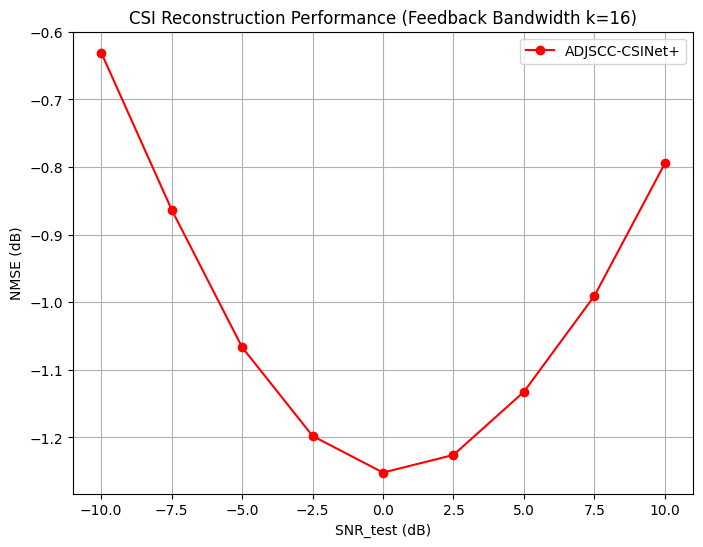

In [34]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def evaluate_performance_curve(data, collater, snr_points=None):
    """
    Evaluates the trained model across a range of fixed SNRs.
    snr_points: list of SNRs in dB to test (e.g., [-10, -5, 0, 5, 10])
    """
    if snr_points is None:
        snr_points = np.linspace(-10, 10, 9) # Matches paper evaluation range [cite: 445, 550]
    
    results = {}
    
    # Set models to evaluation mode
    atn.eval(); encoder.eval(); decoder.eval(); stn.eval()
    
    print("Starting SNR Evaluation...")
    with torch.no_grad():
        for test_snr in snr_points:
            total_nmse = 0.0
            # Use the full test partition (50,000 samples)
            # 50,000 / batch_size(200) = 250 steps
            num_test_steps = 50000 // collater.batch_size 
            
            for _ in range(num_test_steps):
                # 1. Get test data
                x_test, _ = collater(data, mode="test")
                x_test = x_test.to(device)
                
                # 2. Fix the SNR for this specific test point
                # Every sample in the batch gets the same test_snr
                snr_fixed = torch.full((collater.batch_size, 1), test_snr, device=device).float()
                
                # 3. Forward Pass (End-to-End)
                t = atn(x_test, snr_fixed)
                c = encoder(t, snr_fixed)
                s = enc_to_complex_and_normalize(c)
                s_hat = channel_sim(s, snr_fixed)
                c_hat = c2r(s_hat)
                t_hat = decoder(c_hat, snr_fixed)
                x_hat = stn(t_hat, snr_fixed)
                
                # 4. Calculate NMSE [cite: 439, 440]
                total_nmse += calculate_nmse(x_test, x_hat).item()
            
            avg_nmse = total_nmse / num_test_steps
            results[test_snr] = avg_nmse
            print(f"SNR: {test_snr:>5} dB | NMSE: {avg_nmse:.2f} dB")
            
    return results

# --- Run Evaluation and Plot ---
snr_range = [-10, -7.5, -5, -2.5, 0, 2.5, 5, 7.5, 10]

perf_data = evaluate_performance_curve(data, collater, snr_range)

plt.figure(figsize=(8, 6))
plt.plot(list(perf_data.keys()), list(perf_data.values()), 'ro-', label='ADJSCC-CSINet+')
plt.xlabel('SNR_test (dB)')
plt.ylabel('NMSE (dB)')
plt.title('CSI Reconstruction Performance (Feedback Bandwidth k=16)')
plt.grid(True)
plt.legend()
plt.show()